# Day 01 — Project Kickoff & Exploration
**Member 1** | Goal: Understand the raw data, define districts, confirm API access

## Objectives
- Load and inspect the raw cotton Excel dataset
- Explore district names, year coverage, and null patterns
- Confirm Open-Meteo API works for our 15 locations
- Define project scope and constants in `config.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('../src')
from config import RAW_COTTON_PATH, LOCATIONS, WEATHER_VARIABLES

print('Config loaded ✓')
print(f'Districts defined: {len(LOCATIONS)}')
print(f'Weather variables: {WEATHER_VARIABLES}')

Config loaded ✓
Districts defined: 15
Weather variables: ['temperature_2m_mean', 'precipitation_sum', 'relative_humidity_2m_mean', 'wind_speed_10m_max']


## 1. Load Raw Cotton Dataset

In [2]:
df_raw = pd.read_excel(RAW_COTTON_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns[:10])} ...')
df_raw.head(10)

Shape: (29, 26)
Columns: ['Region', 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008] ...


,Region,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aghsu district,5.3,10.7,14.6,28.8,18.1,11.9,13,14.3,12.1,...,-,9.4,11.2,7.6,9.9,25.4,-,-,-,-
1,Ganja city,-,-,26.2,12.8,19.7,18.5,21.5,-,-,...,-,-,-,-,-,-,-,-,-,-
2,Goranboy district,11.9,12.4,24.8,16.7,11.6,11.9,11.3,14.1,14.4,...,7,17.9,13.9,18.3,23.5,34.7,27.8,26.8,27.4,28.6
3,Samukh district,23.3,26,-,-,-,15,-,8.7,21.1,...,16.3,23.1,8.8,23.1,-,21.5,-,-,-,-
4,Aghjabadi district,10.2,13.2,19.5,17.2,15.1,16.7,13.2,15,8.6,...,15.5,24.2,21.5,23.3,30.7,35.5,30.5,34.1,31.5,28.5
5,Aghdam district,7,8.9,14.7,17.7,15,19.7,8.4,12,2.6,...,19.8,21.4,20.6,18.8,28.1,33.5,28.1,28.9,30,22
6,Aghdara district,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,37.9
7,Barda district,13.4,12.4,15.2,16.1,18.2,24.3,19.1,12.9,15.7,...,28.3,23.2,26.3,26.3,33.7,35,27.8,32.6,31.4,29.8
8,Fuzuli district,6.7,8.5,9.8,15,10.5,14.5,8.7,8,0.4,...,4.5,10.3,10.4,10.6,20.4,26.8,22.2,26.6,-,-
9,Khojaly district,3.4,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


## 2. Inspect District Names

In [3]:
districts = df_raw.iloc[:, 0].dropna().unique()
print(f'Total districts in file: {len(districts)}')
for d in sorted(districts):
    print(f'  {d}')

Total districts in file: 29
  Agdash district
  Aghdam district 
  Aghdara district
  Aghjabadi district 
  Aghsu district
  Barda district 
  Beylagan district
  Bilasuvar district
  Fuzuli district 
  Ganja city
  Goranboy district
  Goychay district
  Hajigabul district
  Imishli district
  Jabrayil district
  Jalilabad district
  Khojaly district 
  Khojavand district 
  Kurdamir district
  Lachin district
  Neftchala district
  Saatli district
  Sabirabad district
  Salyan district
  Samukh district
  Tartar district 
  Ujar district
  Yevlakh district
  Zardab district


## 3. Reshape Wide → Long & Check Nulls

In [4]:
df = df_raw.rename(columns={df_raw.columns[0]: 'region'})
df_long = df.melt(id_vars='region', var_name='year', value_name='yield_tonnes')
df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
df_long = df_long.dropna(subset=['year'])
df_long['year'] = df_long['year'].astype(int)

print(f'Long format shape: {df_long.shape}')
print(f'Years covered: {df_long.year.min()} – {df_long.year.max()}')
print(f'Null yield_tonnes: {df_long.yield_tonnes.isnull().sum()}')

# Which districts have nulls?
null_districts = df_long[df_long['yield_tonnes'].isnull()]['region'].unique()
print(f'\nDistricts with nulls ({len(null_districts)}):')
for d in sorted(null_districts):
    print(f'  ✗ {d}')

Long format shape: (725, 3)
Years covered: 2000 – 2024
Null yield_tonnes: 0

Districts with nulls (0):


## 4. Visualise Yield Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_8796\123811226.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long['yield_tonnes'].replace(['-', '…', '...'], np.nan),


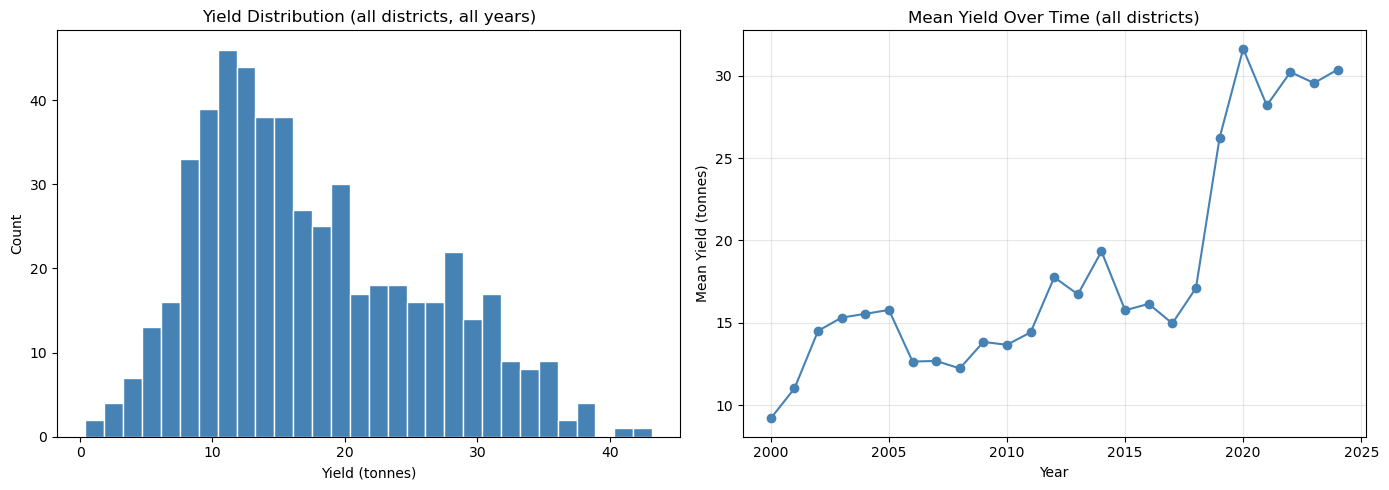

In [7]:
df = df_raw.rename(columns={df_raw.columns[0]: 'region'})
df_long = df.melt(id_vars='region', var_name='year', value_name='yield_tonnes')
df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
df_long = df_long.dropna(subset=['year'])
df_long['year'] = df_long['year'].astype(int)

# Convert string placeholders to NaN before any numeric operation
df_long['yield_tonnes'] = pd.to_numeric(
    df_long['yield_tonnes'].replace(['-', '…', '...'], np.nan),
    errors='coerce'
)

df_clean = df_long.dropna(subset=['yield_tonnes']) 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['yield_tonnes'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Yield Distribution (all districts, all years)')
axes[0].set_xlabel('Yield (tonnes)')
axes[0].set_ylabel('Count')

# Yield over time (mean across districts)
yearly = df_clean.groupby('year')['yield_tonnes'].mean()
axes[1].plot(yearly.index, yearly.values, marker='o', color='steelblue')
axes[1].set_title('Mean Yield Over Time (all districts)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Yield (tonnes)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Confirm Our 15 Districts

In [8]:
from config import LOCATIONS

our_districts = set(LOCATIONS.keys())
data_districts = set(df_clean['region'].unique())

matched = our_districts & data_districts
missing = our_districts - data_districts

print(f'Our 15 districts: {len(our_districts)}')
print(f'Matched in data:  {len(matched)}')
if missing:
    print(f'Missing from data: {missing}')

Our 15 districts: 15
Matched in data:  11
Missing from data: {'Barda district', 'Tartar district', 'Aghjabadi district', 'Aghdam district'}


## 6. Test Open-Meteo API (one district)

In [9]:
import requests_cache
from retry_requests import retry
import openmeteo_requests

cache_session = requests_cache.CachedSession('.weather_cache', expire_after=-1)
retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
client = openmeteo_requests.Client(session=retry_session)

# Test with Goranboy
test_loc = list(LOCATIONS.items())[0]
name, info = test_loc

params = {
    'latitude':   info['lat'],
    'longitude':  info['lon'],
    'start_date': '2020-01-01',
    'end_date':   '2020-12-31',
    'daily':      WEATHER_VARIABLES,
    'timezone':   'Asia/Baku'
}

responses = client.weather_api('https://archive-api.open-meteo.com/v1/archive', params=params)
daily = responses[0].Daily()
print(f'API test for {name}: ✓')
print(f'  Records returned: {daily.Variables(0).ValuesAsNumpy().shape[0]} days')

API test for Goranboy district: ✓
  Records returned: 366 days


## 7. District Map (coordinates)

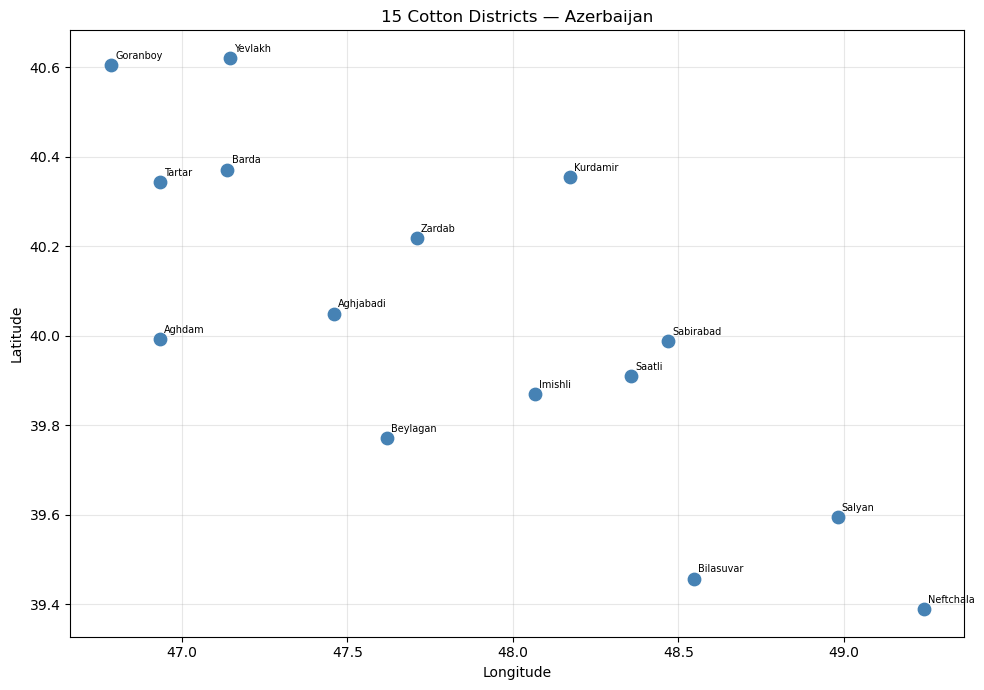

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

for name, info in LOCATIONS.items():
    ax.scatter(info['lon'], info['lat'], s=80, color='steelblue', zorder=5)
    ax.annotate(
        name.replace(' district', ''),
        (info['lon'], info['lat']),
        fontsize=7, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

ax.set_title('15 Cotton Districts — Azerbaijan')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary
- Raw cotton data loaded: wide format, reshaped to long ✓
- Districts with nulls identified — will be dropped in cleaning ✓
- Our 15 target districts confirmed in dataset ✓
- Open-Meteo API accessible ✓
- **Next:** `day_02_ingestion.ipynb` — fetch all weather data